In [1]:
# ============================================================
# === CELL 1: Package Installation ===
# ============================================================
# All package installations

!pip install --quiet "groq>=0.13.0"
!pip install --quiet "yfinance>=0.2.54"
!pip install --quiet "pydantic>=2.0,<3.0"
!pip install --quiet "duckduckgo-search>=6.2.6"
!pip install --quiet requests
print("All packages installed.")
import groq, yfinance, pydantic
print(f" groq : {groq.__version__}")
print(f" yfinance : {yfinance.__version__}")
print(f" pydantic : {pydantic.__version__}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 86.9 MB/s eta 0:00:00
All packages installed.
 groq : 1.7.0
 yfinance : 0.2.66
 pydantic : 2.13.4


In [2]:
# ============================================================
# === CELL 2: Configuration Constants ===
# ============================================================
# Ticker
TICKER = "AAPL"

# Data window
DATA_LOOKBACK_DAYS = 900  # 900 calendar days ~640 trading days

# Technical indicator parameters
SMA_SHORT_WINDOW = 50
SMA_LONG_WINDOW  = 200
RSI_PERIOD       = 14
MACD_FAST        = 12
MACD_SLOW        = 26
MACD_SIGNAL      = 9
BB_WINDOW        = 20
BB_STD_MULT      = 2

# News retrieval
MIN_HEADLINES = 10
MAX_HEADLINES = 20

# Groq model configuration
# Primary: openai/gpt-oss-20b
GROQ_MODEL = "openai/gpt-oss-20b"
GROQ_MODEL_FALLBACKS = [
    "openai/gpt-oss-20b",
    "openai/gpt-oss-120b",
    "qwen/qwen3.6-27b",
]
LLM_TEMPERATURE = 0.1   # Near-deterministic for financial signals
LLM_MAX_TOKENS  = 1024  # Sufficient for JSON

# Momentum signal thresholds
RSI_OVERBOUGHT = 70
RSI_OVERSOLD   = 30
MOMENTUM_WEIGHTS = {
    "sma_cross": 0.35,
    "rsi"      : 0.30,
    "macd"     : 0.20,
    "bb"       : 0.15,
}

# 52-week window in trading days
WEEK_52_DAYS = 252

print("Configuration constants loaded.")
print(f" Ticker        : {TICKER}")
print(f" Lookback      : {DATA_LOOKBACK_DAYS} calendar days")
print(f" SMA windows   : {SMA_SHORT_WINDOW} / {SMA_LONG_WINDOW}")
print(f" RSI period    : {RSI_PERIOD}")
print(f" MACD params   : ({MACD_FAST}, {MACD_SLOW}, {MACD_SIGNAL})")
print(f" Bollinger Band: window={BB_WINDOW}, std_mult={BB_STD_MULT}")
print(f" Groq primary  : {GROQ_MODEL}")
print(f" Groq fallbacks: {GROQ_MODEL_FALLBACKS[1:]}")


Configuration constants loaded.
 Ticker        : AAPL
 Lookback      : 900 calendar days
 SMA windows   : 50 / 200
 RSI period    : 14
 MACD params   : (12, 26, 9)
 Bollinger Band: window=20, std_mult=2
 Groq primary  : openai/gpt-oss-20b
 Groq fallbacks: ['openai/gpt-oss-120b', 'qwen/qwen3.6-27b']


In [3]:
# ============================================================
# === CELL 3: API Key Loading + Model Validation ===
# ============================================================
import os
import requests as _requests


def load_groq_api_key() -> str:
    """
    Load the Groq API key from Google Colab Secrets or environment variables.
    """
    api_key = None
    try:
        from google.colab import userdata
        api_key = userdata.get("GROQ_API_KEY")
        if api_key:
            print(f"Groq API key loaded from Colab Secrets (length={len(api_key)}).")
    except Exception:
        pass

    if not api_key:
        api_key = os.getenv("GROQ_API_KEY")
        if api_key:
            print(f"Groq API key loaded from environment variable (length={len(api_key)}).")

    if not api_key:
        raise EnvironmentError(
            "GROQ_API_KEY not found."
        )
    return api_key


def fetch_live_groq_models(api_key: str) -> list:
    """
    Query the Groq /v1/models endpoint to retrieve all currently active model IDs.

    """
    try:
        resp = _requests.get(
            "https://api.groq.com/openai/v1/models",
            headers={
                "Authorization": f"Bearer {api_key}",
                "Content-Type" : "application/json",
            },
            timeout=10,
        )
        resp.raise_for_status()
        data = resp.json()
        ids = sorted([m["id"] for m in data.get("data", [])])
        print(f" Live Groq models available ({len(ids)} total): {ids}")
        return ids
    except Exception as exc:
        print(f" Could not fetch live model list: {exc}")
        return []


def validate_and_select_groq_model(
    client  : "Groq",
    api_key : str,
    preferred: list,
) -> str:
    """
    Select the first working Groq model by probing each candidate in order.

    Args:
        client   : Initialised Groq client.
        api_key  : Valid Groq API key (used for live model list fetch).
        preferred: Ordered list of preferred model ID strings.

    Returns:
        ID string of the first model that responds to a probe request.

    Raises:
        RuntimeError: If no model responds successfully.
    """
    probe_messages = [
        {"role": "system", "content": "Reply with exactly one word: OK"},
        {"role": "user",   "content": "Say OK"},
    ]

    print("\n Stage 1: Trying preferred model list...")
    for model_id in preferred:
        try:
            resp = client.chat.completions.create(
                model       = model_id,
                messages    = probe_messages,
                temperature = 0.0,
                max_tokens  = 5,
            )
            reply = resp.choices[0].message.content.strip()
            print(f" {model_id} -- '{reply}' -- REACHABLE")
            return model_id
        except Exception as exc:
            short = str(exc)[:110]
            print(f" {model_id} -- {short}")

    print("\n Stage 2: Preferred list exhausted. Fetching live model list from Groq API...")
    live_ids = fetch_live_groq_models(api_key)

    # Exclude audio, vision-only, guard, and TTS models
    skip_keywords   = ["whisper", "guard", "orpheus", "vision", "safeguard"]
    text_candidates = [
        mid for mid in live_ids
        if not any(kw in mid.lower() for kw in skip_keywords)
        and mid not in preferred
    ]
    print(f" Text-generation candidates from live list: {text_candidates}")

    for model_id in text_candidates:
        try:
            resp = client.chat.completions.create(
                model       = model_id,
                messages    = probe_messages,
                temperature = 0.0,
                max_tokens  = 5,
            )
            reply = resp.choices[0].message.content.strip()
            print(f" {model_id} -- '{reply}' -- REACHABLE")
            return model_id
        except Exception as exc:
            short = str(exc)[:110]
            print(f" {model_id} -- {short}")

    raise RuntimeError(
        "No working Groq model found after exhausting all candidates.\n"
        "Check your API key at https://console.groq.com/keys"
    )


GROQ_API_KEY = load_groq_api_key()
from groq import Groq
groq_client = Groq(api_key=GROQ_API_KEY)
print("Groq client initialised.")

print(f"\nValidating Groq model availability (primary: {GROQ_MODEL})...")
GROQ_MODEL = validate_and_select_groq_model(
    client    = groq_client,
    api_key   = GROQ_API_KEY,
    preferred = GROQ_MODEL_FALLBACKS,
)

import groq as _groq_check
print(f"\nActive Groq model confirmed : {GROQ_MODEL}")
print(f" groq SDK version           : {_groq_check.__version__}")


Groq API key loaded from Colab Secrets (length=56).
Groq client initialised.

Validating Groq model availability (primary: openai/gpt-oss-20b)...

 Stage 1: Trying preferred model list...
 openai/gpt-oss-20b -- '' -- REACHABLE

Active Groq model confirmed : openai/gpt-oss-20b
 groq SDK version           : 1.7.0


In [4]:
# ============================================================
# === CELL 4: Imports ===
# ============================================================

# Standard library
import json
import logging
import base64
import io
import textwrap
import time
from datetime import datetime, timedelta
from typing import Optional, List, Dict, Any

# Third-party: data
import numpy as np
import pandas as pd
import yfinance as yf

# Third-party: HTTP utilities
import requests

# Third-party: LLM output validation
from pydantic import BaseModel, Field, field_validator, ValidationError

# Third-party: visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Third-party: news fallback search
from duckduckgo_search import DDGS

# Third-party: notebook display
from IPython.display import HTML, display

logging.basicConfig(
    level   = logging.INFO,
    format  = "%(asctime)s [%(levelname)s] %(message)s",
    datefmt = "%H:%M:%S",
)
logger = logging.getLogger("equity_research")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print("All imports successful.")
print(f" pandas  : {pd.__version__}")
print(f" numpy   : {np.__version__}")
print(f" datetime: {datetime.today().strftime('%Y-%m-%d')}")


All imports successful.
 pandas  : 2.2.3
 numpy   : 2.1.3
 datetime: 2026-09-01


In [5]:
# ============================================================
# === CELL 5: Prompt Constants ===
# ============================================================
# All prompt text is defined as module-level string constants.
# Business logic functions reference these constants by name.

# Sentiment Analysis Prompts
SENTIMENT_SYSTEM_PROMPT = """You are a financial news sentiment analyst.
Your task is to analyse a single news headline and return a structured JSON object.
You must return ONLY valid JSON with exactly these four fields:
- "headline": the original headline text (string)
- "sentiment": one of exactly "positive", "negative", or "neutral" (string)
- "confidence": a float between 0.0 and 1.0 representing your certainty (float)
- "brief_reason": a one-sentence explanation of why you assigned that sentiment (string)
Do NOT include any text, markdown, code fences, or explanation outside the JSON object.
Return ONLY the raw JSON object starting with { and ending with }."""

SENTIMENT_USER_TEMPLATE = """Analyse the sentiment of the following financial news headline for {ticker}:
Headline: "{headline}"
Return only the JSON object with fields: headline, sentiment, confidence, brief_reason."""

# Trading Signal Prompts
SIGNAL_SYSTEM_PROMPT = """You are a senior quantitative equity analyst with 20 years of experience.
Your task is to synthesise multiple technical indicators into a single actionable trading signal.
CRITICAL INSTRUCTIONS — READ CAREFULLY:
1. You must reason about how the indicators INTERACT and CONFIRM or CONTRADICT each other.
2. Do NOT merely restate the individual numeric values of each indicator.
3. Your justification must explicitly address:
   (a) Whether the SMA crossover trend signal aligns with RSI momentum direction.
   (b) Whether the MACD histogram direction confirms or contradicts the SMA trend.
   (c) Whether the Bollinger Band position supports or warns against the trend conclusion.
   (d) How the combination of these signals together justifies the final Buy/Hold/Sell decision.
4. Return ONLY valid JSON with exactly these three fields:
   - "signal": one of exactly "Buy", "Hold", or "Sell" (string)
   - "confidence": a float between 0.0 and 1.0 (float)
   - "justification": exactly 3 to 5 complete sentences reasoning over indicator COMBINATIONS (string)
Do NOT include any text, markdown, code fences, or explanation outside the JSON object.
Return ONLY the raw JSON object starting with { and ending with }."""

SIGNAL_USER_TEMPLATE = """Synthesise the following technical indicators for {ticker} into a
Buy, Hold, or Sell signal. You must reason over how the indicators interact — do they confirm
or contradict each other?
Technical Indicators (latest values):
- 50-day SMA        : {sma_50:.4f}
- 200-day SMA       : {sma_200:.4f}
- SMA Cross State   : Price is {sma_cross_desc} (current price={current_price:.4f})
- RSI-14            : {rsi:.2f} — interpretation: {rsi_desc}
- MACD Line         : {macd_line:.4f}
- MACD Signal Line  : {macd_signal:.4f}
- MACD Histogram    : {macd_hist:.4f} — interpretation: {macd_hist_desc}
- BB Upper Band     : {bb_upper:.4f}
- BB Middle Band    : {bb_middle:.4f}
- BB Lower Band     : {bb_lower:.4f}
- BB Band Position  : Price is at {bb_pct:.1f}% of the band width from the lower band
- News Sentiment    : {overall_sentiment} (aggregated confidence-weighted score: {sentiment_score:.3f})
Your justification MUST address: (a) SMA+RSI alignment, (b) MACD confirmation or divergence,
(c) Bollinger Band position implication, (d) overall synthesis. Do not restate individual values.
Return only the JSON object with fields: signal, confidence, justification."""

print("Prompt constants loaded.")
print(f" SENTIMENT_SYSTEM_PROMPT : {len(SENTIMENT_SYSTEM_PROMPT)} chars")
print(f" SIGNAL_SYSTEM_PROMPT    : {len(SIGNAL_SYSTEM_PROMPT)} chars")
print(f" SENTIMENT_USER_TEMPLATE : {len(SENTIMENT_USER_TEMPLATE)} chars")
print(f" SIGNAL_USER_TEMPLATE    : {len(SIGNAL_USER_TEMPLATE)} chars")


Prompt constants loaded.
 SENTIMENT_SYSTEM_PROMPT : 641 chars
 SIGNAL_SYSTEM_PROMPT    : 1212 chars
 SENTIMENT_USER_TEMPLATE : 187 chars
 SIGNAL_USER_TEMPLATE    : 1159 chars


In [6]:

# ============================================================
# === CELL 6: Pydantic v2 Validation Models ===
# ============================================================

class HeadlineSentiment(BaseModel):
    """
    Validated schema for per-headline LLM sentiment output.

    """
    headline    : str   = Field(..., min_length=1,               description="Original headline text")
    sentiment   : str   = Field(...,                             description="One of: positive, negative, neutral")
    confidence  : float = Field(..., ge=0.0, le=1.0,            description="Certainty score [0,1]")
    brief_reason: str   = Field(..., min_length=1,               description="One-sentence rationale")

    @field_validator("sentiment")
    @classmethod
    def sentiment_must_be_valid(cls, v: str) -> str:
        """Enforce exactly one of three allowed sentiment labels."""
        allowed    = {"positive", "negative", "neutral"}
        normalised = v.strip().lower()
        if normalised not in allowed:
            raise ValueError(
                f"Sentiment '{v}' is not one of {allowed}. "
                "LLM returned an unexpected label."
            )
        return normalised

    @field_validator("confidence")
    @classmethod
    def confidence_must_be_in_range(cls, v: float) -> float:
        """Reject confidence values outside [0, 1]."""
        if not (0.0 <= v <= 1.0):
            raise ValueError(f"Confidence {v} is outside [0, 1].")
        return round(v, 4)


class TradingSignal(BaseModel):
    """
    Validated schema for the LLM Buy/Hold/Sell signal output.

    """
    signal        : str   = Field(...,                  description="One of: Buy, Hold, Sell")
    confidence    : float = Field(..., ge=0.0, le=1.0,  description="Certainty score [0,1]")
    justification : str   = Field(..., min_length=50,   description="3-5 sentence reasoning")

    @field_validator("signal")
    @classmethod
    def signal_must_be_valid(cls, v: str) -> str:
        """Enforce exactly one of three allowed trading signals."""
        allowed    = {"Buy", "Hold", "Sell"}
        normalised = v.strip().title()
        if normalised not in allowed:
            raise ValueError(
                f"Signal '{v}' is not one of {allowed}. "
                "LLM returned an unexpected label."
            )
        return normalised

    @field_validator("confidence")
    @classmethod
    def confidence_must_be_in_range(cls, v: float) -> float:
        """Reject confidence values outside [0, 1]."""
        if not (0.0 <= v <= 1.0):
            raise ValueError(f"Confidence {v} is outside [0, 1].")
        return round(v, 4)


# Safe fallback objects returned when validation fails
SENTIMENT_FALLBACK = HeadlineSentiment(
    headline    = "[PARSE ERROR]",
    sentiment   = "neutral",
    confidence  = 0.0,
    brief_reason= "LLM response failed Pydantic validation",
)

SIGNAL_FALLBACK = TradingSignal(
    signal        = "Hold",
    confidence    = 0.0,
    justification = (
        "LLM response failed Pydantic validation. "
        "Defaulting to a conservative Hold signal. "
        "Manual review of raw indicator values is recommended. "
        "No automated trading action should be taken based on this output. "
        "Please rerun the pipeline or inspect the logs for the raw LLM response."
    ),
)

print("Pydantic v2 models defined.")
print(f" HeadlineSentiment fields: {list(HeadlineSentiment.model_fields.keys())}")
print(f" TradingSignal fields    : {list(TradingSignal.model_fields.keys())}")


Pydantic v2 models defined.
 HeadlineSentiment fields: ['headline', 'sentiment', 'confidence', 'brief_reason']
 TradingSignal fields    : ['signal', 'confidence', 'justification']


In [7]:
# ============================================================
# === CELL 7: Task 1A - OHLCV Data Fetch ===
# ============================================================

def fetch_ohlcv(ticker: str, lookback_days: int) -> pd.DataFrame:
    """
    Fetch daily OHLCV data from Yahoo Finance for a given ticker.

    """
    # Dynamic date range — no hardcoded date strings
    end_date   = datetime.today()
    start_date = end_date - timedelta(days=lookback_days)
    start_str  = start_date.strftime("%Y-%m-%d")
    end_str    = end_date.strftime("%Y-%m-%d")

    logger.info(f"Fetching OHLCV for {ticker} from {start_str} to {end_str}.")

    raw = None

    # Method 1: yf.download()
    try:
        raw = yf.download(
            tickers     = ticker,
            start       = start_str,
            end         = end_str,
            auto_adjust = True,
            progress    = False,
        )
        if raw is not None and not raw.empty:
            logger.info(f"Method 1 (yf.download) succeeded: {len(raw)} rows.")
        else:
            logger.warning("Method 1 (yf.download) returned empty. Trying Method 2.")
            raw = None
    except Exception as exc:
        logger.warning(f"Method 1 (yf.download) raised: {exc}. Trying Method 2.")
        raw = None

    # Method 2: yf.Ticker().history()
    if raw is None or raw.empty:
        try:
            stock = yf.Ticker(ticker)
            raw   = stock.history(start=start_str, end=end_str, auto_adjust=True)
            if raw is not None and not raw.empty:
                logger.info(f"Method 2 (Ticker.history) succeeded: {len(raw)} rows.")
            else:
                raw = None
        except Exception as exc:
            logger.warning(f"Method 2 (Ticker.history) raised: {exc}.")
            raw = None

    if raw is None or raw.empty:
        raise RuntimeError(
            f"No data returned for ticker '{ticker}' from any method. "
        )

    # Flatten MultiIndex columns yfinance sometimes introduces
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    raw.columns = [c.strip().title() for c in raw.columns]

    required_cols = ["Open", "High", "Low", "Close", "Volume"]
    missing_cols  = [c for c in required_cols if c not in raw.columns]
    if missing_cols:
        raise RuntimeError(
            f"Downloaded data is missing columns: {missing_cols}. "
            f"Available columns: {list(raw.columns)}"
        )

    df = raw[required_cols].copy()

    # Strip timezone from DatetimeIndex
    if hasattr(df.index, "tz") and df.index.tz is not None:
        df.index = df.index.tz_localize(None)

    df.dropna(how="all", inplace=True)

    df[["Open", "High", "Low", "Close"]] = (
        df[["Open", "High", "Low", "Close"]].ffill()
    )
    df["Volume"] = df["Volume"].fillna(0)

    if len(df) < WEEK_52_DAYS:
        logger.warning(
            f"Only {len(df)} rows returned; expected at least {WEEK_52_DAYS}. "
            "Indicators requiring long windows may contain NaN in early rows."
        )

    logger.info(f"OHLCV fetch complete: {df.shape[0]} rows, {df.shape[1]} columns.")
    return df


ohlcv_df = fetch_ohlcv(TICKER, DATA_LOOKBACK_DAYS)

print("\n" + "="*60)
print(f"OHLCV Data for {TICKER}")
print("="*60)
print(f"Shape      : {ohlcv_df.shape} ({ohlcv_df.shape[0]} trading days x {ohlcv_df.shape[1]} columns)")
print(f"Date range : {ohlcv_df.index[0].date()} -> {ohlcv_df.index[-1].date()}")
print(f"\nFirst 5 rows:")
print(ohlcv_df.head().to_string())
print(f"\nLast 5 rows:")
print(ohlcv_df.tail().to_string())
print(f"\nNull count per column:")
print(ohlcv_df.isnull().sum().to_string())
print(f"\nMinimum 2-year coverage check: {ohlcv_df.shape[0]} rows >= {WEEK_52_DAYS*2} expected trading days")




OHLCV Data for AAPL
Shape      : (617, 5) (617 trading days x 5 columns)
Date range : 2024-03-15 -> 2026-08-31

First 5 rows:
                  Open        High         Low       Close     Volume
Date                                                                 
2024-03-15  169.324108  170.758469  168.453593  170.758469  121752700
2024-03-18  173.676644  175.793565  171.648748  171.846588   75604200
2024-03-19  172.459896  174.705420  171.164026  174.181137   55215200
2024-03-20  173.825011  176.743195  173.201800  176.743195   53423100
2024-03-21  175.140665  175.575923  168.997628  169.521912  106181300

Last 5 rows:
                  Open        High         Low       Close    Volume
Date                                                                
2026-08-25  310.790009  313.589996  308.209991  309.899994  25869800
2026-08-26  310.299988  315.429993  308.799988  313.450012  34024500
2026-08-27  310.549988  315.399994  309.399994  314.579987  32419200
2026-08-28  316.850006  

In [8]:

# ============================================================
# === CELL 8: Task 1A - Technical Indicators ===
# ============================================================

def compute_sma(series: pd.Series, window: int) -> pd.Series:
    """
    Compute Simple Moving Average over a rolling window.

    Formula: SMA_t = (1/window) * sum(price_{t-window+1} ... price_t)

    """
    return series.rolling(window=window, min_periods=window).mean()


def compute_rsi(series: pd.Series, period: int) -> pd.Series:
    """
    Compute the Relative Strength Index using Wilder's exponential smoothing.

    Wilder RSI algorithm:
        1. Compute day-over-day differences: delta_t = close_t - close_{t-1}
        2. Separate into gains (delta > 0) and losses (abs(delta) when delta < 0)
        3. Seed smoothing with the simple mean of the first `period` values
        4. Wilder smoothing: avg_gain_t = (avg_gain_{t-1} * (period-1) + gain_t) / period
        5. RS = avg_gain / avg_loss
        6. RSI = 100 - (100 / (1 + RS))

    Note: Wilder smoothing uses alpha=1/period via ewm(com=period-1), NOT standard
    EMA alpha=2/(period+1).

    """
    delta = series.diff(1)
    gain  = delta.clip(lower=0)
    loss  = (-delta).clip(lower=0)

    # com=(period-1) gives alpha=1/period, matching Wilder's definition
    avg_gain = gain.ewm(com=(period - 1), adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(com=(period - 1), adjust=False, min_periods=period).mean()

    # avg_loss=0 implies all-gain periods; RSI is clamped to 100
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    rsi = rsi.fillna(100)
    return rsi


def compute_macd(
    series       : pd.Series,
    fast         : int,
    slow         : int,
    signal_period: int,
) -> pd.DataFrame:
    """
    Compute MACD line, signal line, and histogram using standard EMA.

    Formulas:
        EMA_fast    = EMA(close, fast_period)   [alpha = 2/(fast+1)]
        EMA_slow    = EMA(close, slow_period)   [alpha = 2/(slow+1)]
        MACD_line   = EMA_fast - EMA_slow
        Signal_line = EMA(MACD_line, signal_period)
        Histogram   = MACD_line - Signal_line

    Note: MACD uses Appel's EMA (alpha=2/(n+1)) via pandas ewm(span=n),
    not Wilder smoothing.

    """
    ema_fast    = series.ewm(span=fast,          adjust=False).mean()
    ema_slow    = series.ewm(span=slow,          adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    macd_signal = macd_line.ewm(span=signal_period, adjust=False).mean()
    macd_hist   = macd_line - macd_signal

    return pd.DataFrame({
        "MACD_line"  : macd_line,
        "MACD_signal": macd_signal,
        "MACD_hist"  : macd_hist,
    }, index=series.index)


def compute_bollinger_bands(
    series : pd.Series,
    window : int,
    num_std: float,
) -> pd.DataFrame:
    """
    Compute Bollinger Bands: middle (SMA), upper, and lower bands.

    Formulas:
        Middle = SMA(close, window)
        Std    = rolling_std(close, window, ddof=1)  [sample std — Bollinger's default]
        Upper  = Middle + num_std * Std
        Lower  = Middle - num_std * Std

    """
    middle = series.rolling(window=window, min_periods=window).mean()
    std    = series.rolling(window=window, min_periods=window).std(ddof=1)
    upper  = middle + num_std * std
    lower  = middle - num_std * std

    return pd.DataFrame({
        "BB_middle": middle,
        "BB_upper" : upper,
        "BB_lower" : lower,
    }, index=series.index)


def build_indicator_dataframe(ohlcv: pd.DataFrame) -> pd.DataFrame:
    """
    Compute all five technical indicators and append them to the OHLCV DataFrame.

    """
    df    = ohlcv.copy()
    close = df["Close"]

    try:
        df["SMA_50"]  = compute_sma(close, SMA_SHORT_WINDOW)
        df["SMA_200"] = compute_sma(close, SMA_LONG_WINDOW)
        df["RSI_14"]  = compute_rsi(close, RSI_PERIOD)

        macd_df = compute_macd(close, MACD_FAST, MACD_SLOW, MACD_SIGNAL)
        df      = pd.concat([df, macd_df], axis=1)

        bb_df = compute_bollinger_bands(close, BB_WINDOW, BB_STD_MULT)
        df    = pd.concat([df, bb_df], axis=1)

    except Exception as exc:
        logger.error(f"Indicator computation failed: {exc}")
        raise RuntimeError(f"Indicator computation failed: {exc}") from exc

    indicator_cols = ["SMA_50", "SMA_200", "RSI_14", "MACD_line", "BB_upper"]
    complete_rows  = df[indicator_cols].dropna().shape[0]
    logger.info(
        f"Indicators computed. {complete_rows} rows have complete indicator data "
        f"(out of {len(df)} total)."
    )
    return df


indicators_df = build_indicator_dataframe(ohlcv_df)

indicator_display_cols = [
    "Close", "SMA_50", "SMA_200", "RSI_14",
    "MACD_line", "MACD_signal", "MACD_hist",
    "BB_upper", "BB_middle", "BB_lower"
]

print("\n" + "="*60)
print(f"Technical Indicators -- {TICKER} (last 5 rows)")
print("="*60)
print(indicators_df[indicator_display_cols].tail(5).round(4).to_string())

sma200_valid  = indicators_df["SMA_200"].notna().sum()
rsi_valid     = indicators_df["RSI_14"].notna().sum()
last_sma200   = indicators_df["SMA_200"].dropna().iloc[-1]
print(f"\nSMA_200 valid rows : {sma200_valid} (expect >= {SMA_LONG_WINDOW})")
print(f"RSI_14 valid rows  : {rsi_valid} (expect >= {RSI_PERIOD + 1})")
print(f"SMA_200 latest val : {last_sma200:.4f} (must be > 0)")



Technical Indicators -- AAPL (last 5 rows)
             Close    SMA_50   SMA_200   RSI_14  MACD_line  MACD_signal  MACD_hist  BB_upper  BB_middle  BB_lower
Date                                                                                                             
2026-08-25  309.90  310.6735  281.4388  47.9341    -1.3666      -1.2237    -0.1428  329.3712   311.3920  293.4128
2026-08-26  313.45  311.0192  281.6621  51.5419    -1.0307      -1.1851     0.1544  323.2055   310.1696  297.1337
2026-08-27  314.58  311.3311  281.8976  52.6662    -0.6657      -1.0813     0.4155  316.9417   309.2414  301.5411
2026-08-28  319.70  311.8112  282.1526  57.4800     0.0363      -0.8577     0.8940  318.7920   309.7942  300.7964
2026-08-31  316.85  312.1932  282.3644  54.1771     0.3585      -0.6145     0.9730  319.4342   310.4788  301.5235

SMA_200 valid rows : 418 (expect >= 200)
RSI_14 valid rows  : 617 (expect >= 15)
SMA_200 latest val : 282.3644 (must be > 0)


In [9]:
# ============================================================
# === CELL 9: Task 1A — News Retrieval with Fallback ===
# ============================================================

def fetch_news_yfinance(ticker: str, max_items: int) -> List[str]:
    """
    Fetch recent news headlines using the yfinance news endpoint.

    """
    try:
        stock = yf.Ticker(ticker)
        news  = stock.news
        if not news:
            logger.warning(f"yfinance returned zero news items for {ticker}.")
            return []

        headlines = []
        for item in news[:max_items]:
            title = None
            if isinstance(item, dict):
                if "content" in item and isinstance(item["content"], dict):
                    title = item["content"].get("title")
                if title is None:
                    title = item.get("title")
            if title and isinstance(title, str) and title.strip():
                headlines.append(title.strip())

        logger.info(f"yfinance returned {len(headlines)} headlines for {ticker}.")
        return headlines
    except Exception as exc:
        logger.warning(f"yfinance news fetch failed: {exc}")
        return []


def fetch_news_duckduckgo(ticker: str, n: int) -> List[str]:
    """
    Fallback news retrieval using DuckDuckGo news search.

    """
    try:
        query     = f"{ticker} stock market news latest analyst"
        headlines = []
        with DDGS() as ddgs:
            results = list(ddgs.news(query, max_results=n))
        for r in results:
            title = r.get("title", "").strip()
            if title:
                headlines.append(title)
        logger.info(f"DuckDuckGo fallback returned {len(headlines)} headlines.")
        return headlines
    except Exception as exc:
        logger.warning(f"DuckDuckGo fallback failed: {exc}")
        return []


def fetch_headlines(
    ticker      : str,
    min_required: int = MIN_HEADLINES,
    max_items   : int = MAX_HEADLINES,
) -> List[str]:
    """
    Retrieve news headlines using yfinance as primary and DuckDuckGo as fallback.

    """
    headlines = fetch_news_yfinance(ticker, max_items)

    if len(headlines) < min_required:
        logger.info(
            f"Only {len(headlines)} headlines from yfinance; "
            f"triggering DuckDuckGo fallback."
        )
        ddg_headlines = fetch_news_duckduckgo(ticker, max_items)
        headlines.extend(ddg_headlines)

    # Deduplicate while preserving insertion order
    seen   = set()
    unique = []
    for h in headlines:
        key = h.lower().strip()
        if key not in seen:
            seen.add(key)
            unique.append(h)
    headlines = unique[:max_items]

    if len(headlines) == 0:
        raise RuntimeError(
            f"No headlines retrieved for {ticker} from any source. "
            "Check network connectivity and API availability."
        )

    if len(headlines) < min_required:
        logger.warning(
            f"Retrieved only {len(headlines)} headlines after both sources; "
            f"minimum required is {min_required}."
        )

    return headlines


headlines_list = fetch_headlines(TICKER)

print("\n" + "="*60)
print(f"News Headlines -- {TICKER} ({len(headlines_list)} retrieved)")
print("="*60)
for idx, h in enumerate(headlines_list, start=1):
    print(f" [{idx:02d}] {h}")

print(f"\nHeadline retrieval complete.")
print(f" Count retrieved : {len(headlines_list)}")
print(f" Minimum required: {MIN_HEADLINES}")
print(f" Status          : {'PASS' if len(headlines_list) >= MIN_HEADLINES else 'WARN -- below minimum'}")



News Headlines -- AAPL (10 retrieved)
 [01] John Ternus's mission: Make Apple more than just an iPhone company
 [02] What Tim Cook told employees on his last day at Apple
 [03] Rewind to 2011: Tim Cook's first Apple product launch as CEO
 [04] Tim Cook Just Handed Apple to John Ternus -- but He's Not Leaving. Here's What It Means for AAPL Stock.
 [05] Sector Update: Tech Stocks Fall Late Afternoon
 [06] Apple's New CEO Inherits a 33x Valuation and an $840 Billion Legacy
 [07] Apple Turns to John Ternus for Its Next Chapter
 [08] Ripe Brings Old School DeFi Farming to Robinhood Chain
 [09] AAPL Stock Sees Best Day In Over A Month – CEO John Ternus Reportedly Touts 'Phenomenal' iPhone Launch In First Memo To Employees
 [10] Apple new CEO Ternus teases "phenomenal" iPhone launch in first memo

Headline retrieval complete.
 Count retrieved : 10
 Minimum required: 10
 Status          : PASS


In [10]:
# ============================================================
# === CELL 10: Task 1A — Summary Dictionary ===
# ============================================================

def compute_momentum_signal(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Derive a composite momentum signal from four technical indicator families.

    Scoring (each component: +1 bullish, 0 neutral, -1 bearish):
        1. SMA Cross  (weight=0.35): +1 golden cross, -1 death cross, 0 transitional
        2. RSI        (weight=0.30): +1 oversold, -1 overbought, 0 neutral
        3. MACD Hist  (weight=0.20): +1 positive histogram, -1 negative
        4. Bollinger  (weight=0.15): +1 below lower band, -1 above upper, 0 within

    Composite in [-1.0, +1.0]:
        > +0.20 -> Bullish
        < -0.20 -> Bearish
        else    -> Neutral

    """
    indicator_cols = ["Close", "SMA_50", "SMA_200", "RSI_14",
                      "MACD_hist", "BB_upper", "BB_lower"]
    complete = df[indicator_cols].dropna()

    if complete.empty:
        logger.error("No complete indicator rows found. Cannot compute momentum signal.")
        return {"label": "Unknown", "score": 0.0, "components": {}, "latest_values": {}}

    latest   = complete.iloc[-1]
    price    = float(latest["Close"])
    sma_50   = float(latest["SMA_50"])
    sma_200  = float(latest["SMA_200"])
    rsi      = float(latest["RSI_14"])
    macd_hist= float(latest["MACD_hist"])
    bb_upper = float(latest["BB_upper"])
    bb_lower = float(latest["BB_lower"])

    # Component 1: SMA crossover
    if price > sma_50 and sma_50 > sma_200:
        sma_score = +1
    elif price < sma_50 and sma_50 < sma_200:
        sma_score = -1
    else:
        sma_score =  0

    # Component 2: RSI contrarian signal
    if rsi < RSI_OVERSOLD:
        rsi_score = +1
    elif rsi > RSI_OVERBOUGHT:
        rsi_score = -1
    else:
        rsi_score =  0

    # Component 3: MACD histogram direction
    macd_score = +1 if macd_hist > 0 else -1

    # Component 4: Bollinger Band position
    if price < bb_lower:
        bb_score = +1
    elif price > bb_upper:
        bb_score = -1
    else:
        bb_score =  0

    composite = (
        MOMENTUM_WEIGHTS["sma_cross"] * sma_score +
        MOMENTUM_WEIGHTS["rsi"]       * rsi_score +
        MOMENTUM_WEIGHTS["macd"]      * macd_score +
        MOMENTUM_WEIGHTS["bb"]        * bb_score
    )
    composite = round(composite, 4)

    if composite > 0.20:
        label = "Bullish"
    elif composite < -0.20:
        label = "Bearish"
    else:
        label = "Neutral"

    return {
        "label"     : label,
        "score"     : composite,
        "components": {
            "sma_cross_score": sma_score,
            "rsi_score"      : rsi_score,
            "macd_hist_score": macd_score,
            "bb_score"       : bb_score,
        },
        "latest_values": {
            "price"    : price,
            "sma_50"   : sma_50,
            "sma_200"  : sma_200,
            "rsi"      : rsi,
            "macd_hist": macd_hist,
            "bb_upper" : bb_upper,
            "bb_lower" : bb_lower,
        },
    }


def build_summary_dict(
    ticker       : str,
    indicators_df: pd.DataFrame,
    momentum     : Dict[str, Any],
) -> Dict[str, Any]:

    close         = indicators_df["Close"].dropna()
    current_price = float(close.iloc[-1])
    window_52w    = close.iloc[-WEEK_52_DAYS:]
    week_52_high  = float(window_52w.max())
    week_52_low   = float(window_52w.min())

    pe_ratio = None
    try:
        stock    = yf.Ticker(ticker)
        info     = stock.info
        pe_ratio = info.get("trailingPE") or info.get("forwardPE") or None
        if pe_ratio:
            pe_ratio = round(float(pe_ratio), 2)
        else:
            logger.warning(f"P/E ratio not available in yfinance info for {ticker}.")
    except Exception as exc:
        logger.warning(f"Failed to fetch P/E ratio: {exc}")
        pe_ratio = None

    # YTD return — current year derived dynamically, no hardcoded year
    current_year  = datetime.today().year
    ytd_start_str = f"{current_year}-01-01"
    ytd_window    = close[close.index >= ytd_start_str]

    if len(ytd_window) < 2:
        logger.warning("Insufficient YTD data. Using last 30 trading days instead.")
        ytd_window = close.iloc[-30:]

    ytd_start_price = float(ytd_window.iloc[0])
    ytd_end_price   = float(ytd_window.iloc[-1])
    ytd_return_pct  = round(
        (ytd_end_price - ytd_start_price) / ytd_start_price * 100, 4
    )

    return {
        "ticker"          : ticker,
        "current_price"   : round(current_price, 4),
        "week_52_high"    : round(week_52_high,  4),
        "week_52_low"     : round(week_52_low,   4),
        "pe_ratio"        : pe_ratio,
        "ytd_return_pct"  : ytd_return_pct,
        "momentum_signal" : momentum,
    }


momentum_result = compute_momentum_signal(indicators_df)
summary_dict    = build_summary_dict(TICKER, indicators_df, momentum_result)

print("\n" + "="*60)
print(f"Equity Summary Dictionary -- {TICKER}")
print("="*60)
print(f" current_price   : ${summary_dict['current_price']:,.4f}")
print(f" week_52_high    : ${summary_dict['week_52_high']:,.4f}")
print(f" week_52_low     : ${summary_dict['week_52_low']:,.4f}")
print(f" pe_ratio        : {summary_dict['pe_ratio']}")
print(f" ytd_return_pct  : {summary_dict['ytd_return_pct']:+.4f}%")
print(f"\n momentum_signal:")
print(f"   label      : {summary_dict['momentum_signal']['label']}")
print(f"   score      : {summary_dict['momentum_signal']['score']:.4f}")
print(f"   components : {json.dumps(summary_dict['momentum_signal']['components'], indent=6)}")
print(f"\n latest indicator values:")
for k, v in summary_dict['momentum_signal']['latest_values'].items():
    print(f"   {k:<12}: {v:.4f}")

required_fields = ["current_price", "week_52_high", "week_52_low",
                   "pe_ratio", "ytd_return_pct", "momentum_signal"]
missing = [f for f in required_fields if f not in summary_dict]
print(f"\nAll required fields present: {len(missing) == 0}")
if missing:
    print(f" Missing: {missing}")




Equity Summary Dictionary -- AAPL
 current_price   : $316.8500
 week_52_high    : $339.7869
 week_52_low     : $225.9553
 pe_ratio        : 37.25
 ytd_return_pct  : +17.2327%

 momentum_signal:
   label      : Bullish
   score      : 0.5500
   components : {
      "sma_cross_score": 1,
      "rsi_score": 0,
      "macd_hist_score": 1,
      "bb_score": 0
}

 latest indicator values:
   price       : 316.8500
   sma_50      : 312.1932
   sma_200     : 282.3644
   rsi         : 54.1771
   macd_hist   : 0.9730
   bb_upper    : 319.4342
   bb_lower    : 301.5235

All required fields present: True


In [11]:
# ============================================================
# === CELL 11: Task 1B - LLM Helper Function ===
# ============================================================

def call_groq_json(
    system_prompt  : str,
    user_prompt    : str,
    pydantic_model : type,
    fallback_object: Any,
    label          : str = "LLM call",
) -> Any:
    """
    Make a Groq API call expecting a JSON response and validate with a Pydantic model.

    """
    raw_response = None
    try:
        chat_completion = groq_client.chat.completions.create(
            model       = GROQ_MODEL,
            messages    = [
                {"role": "system", "content": system_prompt},
                {"role": "user",   "content": user_prompt},
            ],
            temperature = LLM_TEMPERATURE,
            max_tokens  = LLM_MAX_TOKENS,
        )

        raw_response = chat_completion.choices[0].message.content

        cleaned = raw_response.strip()
        if cleaned.startswith("```"):
            lines   = cleaned.split("\n")
            lines   = [l for l in lines if not l.strip().startswith("```")]
            cleaned = "\n".join(lines).strip()

        parsed_dict = json.loads(cleaned)
        validated   = pydantic_model.model_validate(parsed_dict)
        return validated

    except json.JSONDecodeError as exc:
        logger.error(
            f"[{label}] JSON parse failed: {exc}\n"
            f"Raw LLM response was:\n{raw_response}"
        )
        return fallback_object
    except ValidationError as exc:
        logger.error(
            f"[{label}] Pydantic validation failed: {exc}\n"
            f"Raw LLM response was:\n{raw_response}"
        )
        return fallback_object
    except Exception as exc:
        logger.error(
            f"[{label}] Unexpected error: {exc}\n"
            f"Raw LLM response was:\n{raw_response}"
        )
        return fallback_object


print("LLM helper function defined.")
print(" call_groq_json pipeline: API call -> fence strip -> JSON parse -> Pydantic validate -> fallback")
print(f" Active model: {GROQ_MODEL}")



LLM helper function defined.
 call_groq_json pipeline: API call -> fence strip -> JSON parse -> Pydantic validate -> fallback
 Active model: openai/gpt-oss-20b


In [12]:
# ============================================================
# === CELL 12: Task 1B - Per-Headline Sentiment Analysis ===
# ============================================================

def analyse_headline_sentiment(
    headline: str,
    ticker  : str,
) -> HeadlineSentiment:
    """
    Analyse the sentiment of a single news headline using the Groq LLM.

    """
    user_prompt = SENTIMENT_USER_TEMPLATE.format(
        ticker   = ticker,
        headline = headline,
    )
    result = call_groq_json(
        system_prompt  = SENTIMENT_SYSTEM_PROMPT,
        user_prompt    = user_prompt,
        pydantic_model = HeadlineSentiment,
        fallback_object= SENTIMENT_FALLBACK,
        label          = f"headline_sentiment[{headline[:45]}]",
    )
    if result is SENTIMENT_FALLBACK:
        return HeadlineSentiment(
            headline    = headline,
            sentiment   = "neutral",
            confidence  = 0.0,
            brief_reason= "LLM validation failed.",
        )
    return result


def analyse_all_headlines(
    headlines     : List[str],
    ticker        : str,
    delay_seconds : float = 0.5,
) -> Dict[str, Any]:
    """
    Run per-headline sentiment analysis across all retrieved headlines.

    """
    sentiment_map   = {"positive": +1.0, "negative": -1.0, "neutral": 0.0}
    results         = []
    total_weighted  = 0.0
    total_weight    = 0.0

    print(f"\nAnalysing {len(headlines)} headlines with {GROQ_MODEL}...")
    print("-" * 65)

    for i, headline in enumerate(headlines):
        result = analyse_headline_sentiment(headline, ticker)
        results.append(result)

        score  = sentiment_map.get(result.sentiment, 0.0)
        weight = result.confidence if result.confidence > 0 else 0.1
        total_weighted += score * weight
        total_weight   += weight

        print(
            f"[{i+1:02d}] {result.sentiment.upper():<8} "
            f"conf={result.confidence:.2f} "
            f"{headline[:58]}{'...' if len(headline) > 58 else ''}"
        )

        if i < len(headlines) - 1:
            time.sleep(delay_seconds)

    overall_score = round(total_weighted / total_weight, 4) if total_weight > 0 else 0.0

    if overall_score > 0.10:
        overall_label = "positive"
    elif overall_score < -0.10:
        overall_label = "negative"
    else:
        overall_label = "neutral"

    sentiment_counts = {"positive": 0, "negative": 0, "neutral": 0}
    for r in results:
        sentiment_counts[r.sentiment] = sentiment_counts.get(r.sentiment, 0) + 1

    return {
        "results"         : results,
        "overall_score"   : overall_score,
        "overall_label"   : overall_label,
        "sentiment_counts": sentiment_counts,
    }


sentiment_results = analyse_all_headlines(headlines_list, TICKER)

print("\n" + "="*60)
print(f"Sentiment Analysis Summary -- {TICKER}")
print("="*60)
print(f" Headlines analysed: {len(sentiment_results['results'])}")
print(f" Positive          : {sentiment_results['sentiment_counts']['positive']}")
print(f" Neutral           : {sentiment_results['sentiment_counts']['neutral']}")
print(f" Negative          : {sentiment_results['sentiment_counts']['negative']}")
print(f" Overall score     : {sentiment_results['overall_score']:+.4f} "
      f"(confidence-weighted mean; range [-1,+1])")
print(f" Overall label     : {sentiment_results['overall_label'].upper()}")

real_calls = sum(1 for r in sentiment_results['results'] if r.confidence > 0.0)
print(f"\n Real LLM responses: {real_calls}/{len(sentiment_results['results'])} "
      f"({'LLM working' if real_calls > 0 else 'All calls failed.'})")

if real_calls > 0:
    sample = next(r for r in sentiment_results['results'] if r.confidence > 0.0)
    print(f"\n Sample validated HeadlineSentiment (schema proof):")
    print(f"   headline    : {sample.headline[:70]}")
    print(f"   sentiment   : {sample.sentiment}")
    print(f"   confidence  : {sample.confidence}")
    print(f"   brief_reason: {sample.brief_reason[:80]}")




Analysing 10 headlines with openai/gpt-oss-20b...
-----------------------------------------------------------------
[01] POSITIVE conf=0.90 John Ternus's mission: Make Apple more than just an iPhone...
[02] NEUTRAL  conf=0.80 What Tim Cook told employees on his last day at Apple
[03] NEUTRAL  conf=0.90 Rewind to 2011: Tim Cook's first Apple product launch as C...
[04] NEUTRAL  conf=0.60 Tim Cook Just Handed Apple to John Ternus -- but He's Not ...
[05] NEGATIVE conf=0.90 Sector Update: Tech Stocks Fall Late Afternoon
[06] POSITIVE conf=0.90 Apple's New CEO Inherits a 33x Valuation and an $840 Billi...
[07] POSITIVE conf=0.80 Apple Turns to John Ternus for Its Next Chapter
[08] NEUTRAL  conf=0.80 Ripe Brings Old School DeFi Farming to Robinhood Chain
[09] POSITIVE conf=0.95 AAPL Stock Sees Best Day In Over A Month – CEO John Ternus...
[10] POSITIVE conf=0.90 Apple new CEO Ternus teases "phenomenal" iPhone launch in ...

Sentiment Analysis Summary -- AAPL
 Headlines analysed: 10
 Positi

In [13]:
# ============================================================
# === CELL 13: Task 1B — Trading Signal Generation ===
# ============================================================

def generate_trading_signal(
    indicators_df: pd.DataFrame,
    summary      : Dict[str, Any],
    sentiment_agg: Dict[str, Any],
) -> TradingSignal:
    """
    Generate a Buy, Hold, or Sell signal by prompting the LLM.

    """
    lv        = summary["momentum_signal"]["latest_values"]
    price     = lv["price"]
    sma_50    = lv["sma_50"]
    sma_200   = lv["sma_200"]
    rsi       = lv["rsi"]
    macd_hist = lv["macd_hist"]
    bb_upper  = lv["bb_upper"]
    bb_lower  = lv["bb_lower"]

    # Contextual descriptions

    # SMA cross: describes trend regime
    if price > sma_50 and sma_50 > sma_200:
        sma_cross_desc = (
            "above both the 50-day and 200-day SMA "
            "(golden cross region -- uptrend confirmed by both averages)"
        )
    elif price < sma_50 and sma_50 < sma_200:
        sma_cross_desc = (
            "below both the 50-day and 200-day SMA "
            "(death cross region -- downtrend confirmed by both averages)"
        )
    elif price > sma_50 and sma_50 < sma_200:
        sma_cross_desc = (
            "above the 50-day SMA but 50-day is still below 200-day "
            "(early recovery phase -- golden cross not yet confirmed)"
        )
    else:
        sma_cross_desc = (
            "between the moving averages "
            "(transitional phase -- trend direction is ambiguous)"
        )

    # RSI: describes momentum state
    if rsi > RSI_OVERBOUGHT:
        rsi_desc = f"overbought at {rsi:.1f} -- momentum may be exhausted and reversal risk elevated"
    elif rsi < RSI_OVERSOLD:
        rsi_desc = f"oversold at {rsi:.1f} -- potential mean-reversion upward, historically a buy signal"
    elif rsi > 55:
        rsi_desc = f"bullish at {rsi:.1f} -- positive momentum without overbought extremes"
    elif rsi < 45:
        rsi_desc = f"bearish at {rsi:.1f} -- weakening momentum without oversold extremes"
    else:
        rsi_desc = f"neutral at {rsi:.1f} -- no strong directional momentum bias"

    # MACD histogram: describes momentum acceleration
    macd_signal_val = float(indicators_df["MACD_signal"].dropna().iloc[-1])
    if macd_hist > 0:
        macd_hist_desc = "positive -- fast EMA is above the slow EMA, indicating bullish short-term momentum"
    else:
        macd_hist_desc = "negative -- fast EMA is below the slow EMA, indicating bearish short-term momentum"

    # Bollinger Band percentage position: 0%=at lower band, 100%=at upper band
    bb_range = bb_upper - bb_lower
    bb_pct   = ((price - bb_lower) / bb_range * 100) if bb_range > 0 else 50.0

    user_prompt = SIGNAL_USER_TEMPLATE.format(
        ticker           = TICKER,
        sma_50           = sma_50,
        sma_200          = sma_200,
        sma_cross_desc   = sma_cross_desc,
        current_price    = price,
        rsi              = rsi,
        rsi_desc         = rsi_desc,
        macd_line        = float(indicators_df["MACD_line"].dropna().iloc[-1]),
        macd_signal      = macd_signal_val,
        macd_hist        = macd_hist,
        macd_hist_desc   = macd_hist_desc,
        bb_upper         = bb_upper,
        bb_middle        = float(indicators_df["BB_middle"].dropna().iloc[-1]),
        bb_lower         = bb_lower,
        bb_pct           = bb_pct,
        overall_sentiment= sentiment_agg["overall_label"],
        sentiment_score  = sentiment_agg["overall_score"],
    )

    signal = call_groq_json(
        system_prompt  = SIGNAL_SYSTEM_PROMPT,
        user_prompt    = user_prompt,
        pydantic_model = TradingSignal,
        fallback_object= SIGNAL_FALLBACK,
        label          = "trading_signal",
    )
    return signal


trading_signal = generate_trading_signal(
    indicators_df = indicators_df,
    summary       = summary_dict,
    sentiment_agg = sentiment_results,
)

print("\n" + "="*60)
print(f"Trading Signal -- {TICKER}")
print("="*60)
print(f" Signal     : {trading_signal.signal}")
print(f" Confidence : {trading_signal.confidence:.4f} ({trading_signal.confidence:.0%})")
print(f"\n Justification:")
for line in textwrap.wrap(trading_signal.justification, width=70):
    print(f"   {line}")

is_fallback = (trading_signal.confidence == 0.0 and trading_signal.signal == "Hold")
print(f"\n LLM status : {'Fallback returned' if is_fallback else 'Real LLM signal generated'}")
print(f" Validation : Pydantic TradingSignal schema validated")
print(f" Schema fields: {list(TradingSignal.model_fields.keys())}")




Trading Signal -- AAPL
 Signal     : Buy
 Confidence : 0.7500 (75%)

 Justification:
   The golden cross confirms a strong uptrend while the neutral RSI
   indicates that the price is not yet overbought, allowing room for
   further upside. The MACD histogram is positive and the line is above
   its signal, reinforcing short‑term bullish momentum that aligns with
   the SMA trend. Bollinger Band placement near the upper band but still
   below the extreme suggests a healthy rally without immediate reversal
   risk. Combined with positive news sentiment, the indicators
   collectively support a Buy decision.

 LLM status : Real LLM signal generated
 Validation : Pydantic TradingSignal schema validated
 Schema fields: ['signal', 'confidence', 'justification']


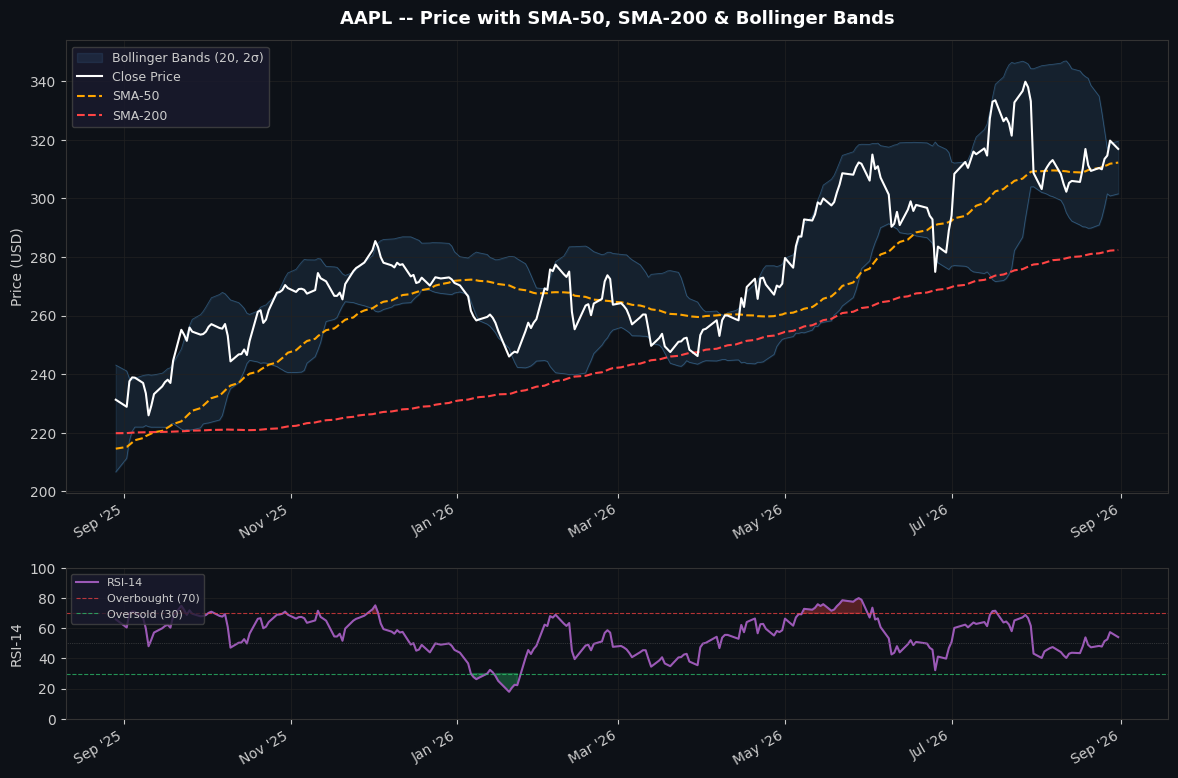


Chart generated and encoded.
 Base64 length: 314,652 chars
 Approx size  : 230 KB uncompressed


In [14]:
# ============================================================
# === CELL 14: Chart Generation ===
# ============================================================

def generate_price_chart_base64(
    df    : pd.DataFrame,
    ticker: str,
    n_days: int = 252,
) -> str:
    """
    Generate a two-panel price chart and return as a PNG string.

    """
    plot_df  = df[["Close", "SMA_50", "SMA_200", "BB_upper", "BB_lower"]].dropna().iloc[-n_days:]
    rsi_plot = df["RSI_14"].dropna().iloc[-n_days:]

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize      = (12, 8),
        gridspec_kw  = {"height_ratios": [3, 1]},
        facecolor    = "#0d1117",
    )
    fig.patch.set_facecolor("#0d1117")

    # Panel 1: Price + SMAs + Bollinger Bands
    ax1.set_facecolor("#0d1117")
    ax1.fill_between(
        plot_df.index, plot_df["BB_upper"], plot_df["BB_lower"],
        alpha=0.15, color="#4682b4",
        label=f"Bollinger Bands ({BB_WINDOW}, {BB_STD_MULT}\u03c3)"
    )
    ax1.plot(plot_df.index, plot_df["BB_upper"], color="#4682b4", linewidth=0.6, alpha=0.5)
    ax1.plot(plot_df.index, plot_df["BB_lower"], color="#4682b4", linewidth=0.6, alpha=0.5)
    ax1.plot(
        plot_df.index, plot_df["Close"],
        color="#ffffff", linewidth=1.5, label="Close Price", zorder=5
    )
    ax1.plot(
        plot_df.index, plot_df["SMA_50"],
        color="#ffa500", linewidth=1.5, linestyle="--",
        label=f"SMA-{SMA_SHORT_WINDOW}"
    )
    ax1.plot(
        plot_df.index, plot_df["SMA_200"],
        color="#ff4444", linewidth=1.5, linestyle="--",
        label=f"SMA-{SMA_LONG_WINDOW}"
    )
    ax1.set_title(
        f"{ticker} -- Price with SMA-{SMA_SHORT_WINDOW}, SMA-{SMA_LONG_WINDOW} & Bollinger Bands",
        color="#ffffff", fontsize=13, fontweight="bold", pad=12
    )
    ax1.set_ylabel("Price (USD)", color="#cccccc", fontsize=10)
    ax1.tick_params(colors="#cccccc")
    ax1.spines[:].set_color("#333333")
    ax1.legend(
        loc="upper left", facecolor="#1a1a2e", edgecolor="#444444",
        labelcolor="#cccccc", fontsize=9
    )
    ax1.grid(color="#222222", linewidth=0.5)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")

    # Panel 2: RSI-14
    ax2.set_facecolor("#0d1117")
    ax2.plot(rsi_plot.index, rsi_plot, color="#9b59b6", linewidth=1.5, label="RSI-14")
    ax2.axhline(RSI_OVERBOUGHT, color="#ff4444", linewidth=0.8, linestyle="--", alpha=0.7,
                label=f"Overbought ({RSI_OVERBOUGHT})")
    ax2.axhline(RSI_OVERSOLD,   color="#2ecc71", linewidth=0.8, linestyle="--", alpha=0.7,
                label=f"Oversold ({RSI_OVERSOLD})")
    ax2.axhline(50, color="#555555", linewidth=0.5, linestyle=":")
    ax2.fill_between(
        rsi_plot.index, rsi_plot, RSI_OVERBOUGHT,
        where=(rsi_plot > RSI_OVERBOUGHT), alpha=0.3, color="#ff4444"
    )
    ax2.fill_between(
        rsi_plot.index, rsi_plot, RSI_OVERSOLD,
        where=(rsi_plot < RSI_OVERSOLD), alpha=0.3, color="#2ecc71"
    )
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("RSI-14", color="#cccccc", fontsize=10)
    ax2.tick_params(colors="#cccccc")
    ax2.spines[:].set_color("#333333")
    ax2.grid(color="#222222", linewidth=0.5)
    ax2.legend(
        loc="upper left", facecolor="#1a1a2e", edgecolor="#444444",
        labelcolor="#cccccc", fontsize=8
    )
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")

    plt.tight_layout(pad=1.5)

    # Encode to base64 in memory
    buffer = io.BytesIO()
    plt.savefig(
        buffer, format="png", dpi=130,
        bbox_inches="tight", facecolor=fig.get_facecolor()
    )
    buffer.seek(0)
    chart_b64 = base64.b64encode(buffer.read()).decode("utf-8")
    plt.show()
    plt.close(fig)

    logger.info(f"Chart encoded as base64 PNG ({len(chart_b64):,} chars).")
    return chart_b64


chart_base64 = generate_price_chart_base64(indicators_df, TICKER)
print(f"\nChart generated and encoded.")
print(f" Base64 length: {len(chart_base64):,} chars")
print(f" Approx size  : {len(chart_base64) * 3 // 4 // 1024} KB uncompressed")



50-day SMA,$312.19
200-day SMA,$282.36
RSI-14,54.18
MACD Hist,0.9730
BB Upper,$319.43
BB Lower,$301.52

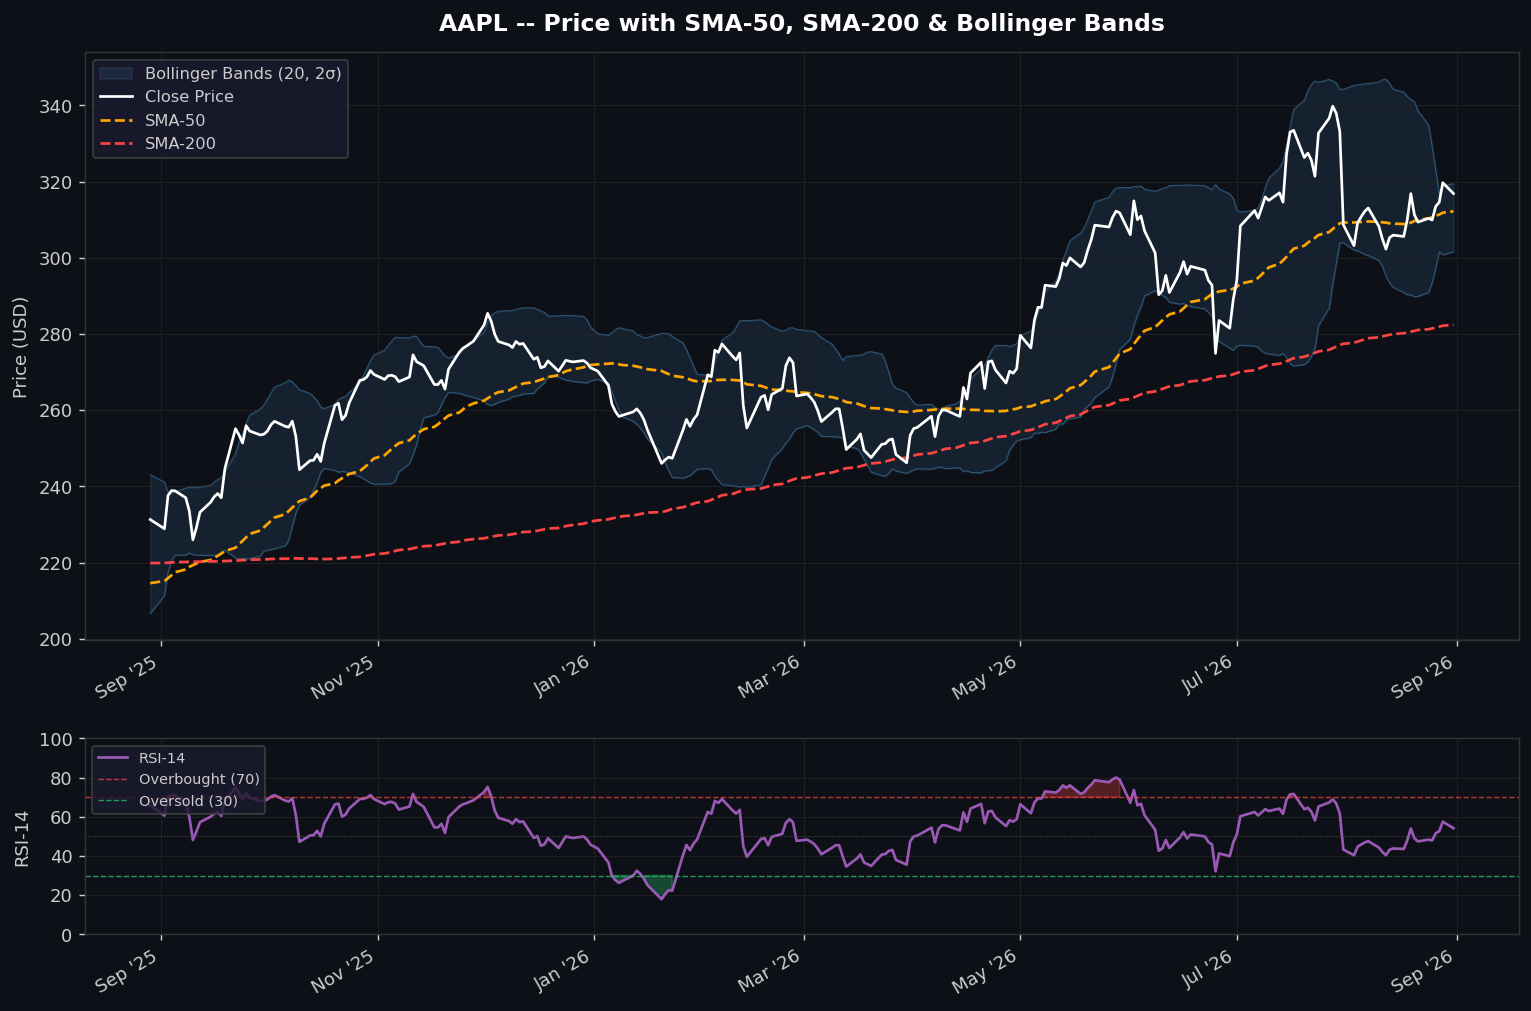

In [15]:
# ============================================================
# === CELL 15: Styled HTML Equity Research Report ===
# ============================================================

def build_html_report(
    ticker        : str,
    summary       : Dict[str, Any],
    sentiment_agg : Dict[str, Any],
    trading_signal: TradingSignal,
    headlines     : List[str],
    chart_b64     : str,
) -> str:
    """
    Compose an equity research brief as styled HTML.
    """
    signal_colors = {"Buy": "#1a9e5c", "Hold": "#b07d2a", "Sell": "#c0392b"}
    sent_colors   = {"positive": "#1a9e5c", "negative": "#c0392b", "neutral": "#8a8fa8"}
    mom_colors    = {"Bullish": "#1a9e5c", "Neutral": "#8a8fa8", "Bearish": "#c0392b"}

    signal_color = signal_colors.get(trading_signal.signal, "#4a5068")
    mom_color    = mom_colors.get(summary["momentum_signal"]["label"], "#4a5068")

    ytd_val   = summary["ytd_return_pct"]
    ytd_color = "#1a9e5c" if ytd_val >= 0 else "#c0392b"
    ytd_str   = f"{ytd_val:+.2f}%"

    top3_results = sentiment_agg["results"][:3]
    top3_html    = ""
    for r in top3_results:
        sc         = sent_colors.get(r.sentiment, "#8a8fa8")
        conf_label = f"{r.confidence:.0%}" if r.confidence > 0 else "N/A"
        sent_upper = r.sentiment.upper()
        top3_html += f"""
        <div style="display:flex; align-items:flex-start; gap:16px; padding:14px 0;
                    border-bottom:1px solid #e8eaed;">
            <div style="flex-shrink:0; min-width:90px; text-align:center;
                        padding:4px 8px; background:{sc}14;
                        border:1px solid {sc}40; border-radius:3px;">
                <div style="color:{sc}; font-size:10px; font-weight:700;
                            letter-spacing:0.8px;">{sent_upper}</div>
                <div style="color:{sc}; font-size:10px; margin-top:1px;
                            font-weight:600; opacity:0.75;">{conf_label}</div>
            </div>
            <div style="flex:1;">
                <div style="color:#111827; font-size:13.5px; font-weight:500;
                            line-height:1.5;">{r.headline}</div>
                <div style="color:#4b5563; font-size:11.5px; margin-top:4px;
                            line-height:1.4;">{r.brief_reason}</div>
            </div>
        </div>"""

    lv = summary["momentum_signal"]["latest_values"]
    indicator_rows = [
        ("50-day SMA",  f"${lv['sma_50']:.2f}"),
        ("200-day SMA", f"${lv['sma_200']:.2f}"),
        ("RSI-14",      f"{lv['rsi']:.2f}"),
        ("MACD Hist",   f"{lv['macd_hist']:.4f}"),
        ("BB Upper",    f"${lv['bb_upper']:.2f}"),
        ("BB Lower",    f"${lv['bb_lower']:.2f}"),
    ]
    ind_table = "".join([
        f"<tr>"
        f"<td style='color:#374151; padding:9px 12px; font-size:12px;"
        f"           font-weight:600; width:50%;'>{k}</td>"
        f"<td style='color:#111827; padding:9px 12px; font-size:13px;"
        f"           font-weight:600; font-variant-numeric:tabular-nums;'>{v}</td>"
        f"</tr>"
        for k, v in indicator_rows
    ])

    bar_pct   = int((sentiment_agg["overall_score"] + 1.0) / 2.0 * 100)
    bar_color = sent_colors.get(sentiment_agg["overall_label"], "#8a8fa8")

    report_date = datetime.today().strftime("%B %d, %Y  |  %H:%M UTC")

    conf_pct = int(trading_signal.confidence * 100)

    html = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>{ticker} Equity Research Brief</title>
    <style>
        * {{ box-sizing: border-box; margin: 0; padding: 0; }}

        body {{
            font-family: -apple-system, 'Helvetica Neue', Arial, sans-serif;
            background: #dde1e7;
            color: #1c2333;
            line-height: 1.6;
            padding: 32px 20px;
            -webkit-font-smoothing: antialiased;
        }}

        .report-container {{
            max-width: 860px;
            margin: 0 auto;
            background: #ffffff;
            border: 1px solid #d1d5db;
            border-radius: 4px;
            overflow: hidden;
            box-shadow: 0 2px 12px rgba(0,0,0,0.10);
        }}

        /* ── Header ──────────────────────────────────────── */
        .report-header {{
            background: #0f1923;
            padding: 32px 40px 28px;
            border-bottom: 3px solid {signal_color};
        }}
        .header-top {{
            display: flex;
            align-items: flex-start;
            justify-content: space-between;
            gap: 24px;
        }}
        .ticker-block {{}}
        .ticker {{
            font-size: 36px;
            font-weight: 700;
            color: #ffffff;
            letter-spacing: 1px;
            line-height: 1;
        }}
        .report-subtitle {{
            font-size: 11px;
            color: #8fa0b8;
            letter-spacing: 1.5px;
            text-transform: uppercase;
            margin-top: 8px;
        }}
        .header-meta {{
            text-align: right;
        }}
        .report-date {{
            font-size: 12px;
            color: #8fa0b8;
            letter-spacing: 0.3px;
        }}
        .report-type-badge {{
            display: inline-block;
            margin-top: 8px;
            padding: 3px 10px;
            border: 1px solid #2a3a50;
            border-radius: 2px;
            font-size: 10px;
            color: #6a80a0;
            letter-spacing: 1px;
            text-transform: uppercase;
        }}

        /* ── Sections ────────────────────────────────────── */
        .section {{
            padding: 28px 40px;
            border-bottom: 1px solid #e8eaed;
        }}
        .section:last-child {{ border-bottom: none; }}

        .section-label {{
            font-size: 10px;
            font-weight: 700;
            letter-spacing: 2px;
            text-transform: uppercase;
            color: #6b7280;
            margin-bottom: 20px;
            display: flex;
            align-items: center;
            gap: 10px;
        }}
        .section-label-num {{
            color: {signal_color};
        }}
        .section-label::after {{
            content: '';
            flex: 1;
            height: 1px;
            background: #e8eaed;
        }}

        /* ── Company Snapshot grid ───────────────────────── */
        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 1px;
            background: #e8eaed;
            border: 1px solid #e8eaed;
            border-radius: 3px;
            overflow: hidden;
        }}
        .stat-card {{
            background: #ffffff;
            padding: 18px 20px;
        }}
        .stat-label {{
            font-size: 10.5px;
            font-weight: 700;
            color: #6b7280;
            text-transform: uppercase;
            letter-spacing: 0.8px;
        }}
        .stat-value {{
            font-size: 22px;
            font-weight: 600;
            color: #0f1923;
            margin-top: 6px;
            line-height: 1.1;
            font-variant-numeric: tabular-nums;
        }}
        .momentum-pill {{
            display: inline-block;
            padding: 3px 10px;
            border-radius: 2px;
            font-size: 13px;
            font-weight: 700;
            letter-spacing: 0.5px;
            color: {mom_color};
            background: {mom_color}14;
            border: 1px solid {mom_color}30;
        }}
        .stat-sub {{
            font-size: 11px;
            color: #6b7280;
            margin-top: 5px;
            font-variant-numeric: tabular-nums;
            font-weight: 500;
        }}

        /* ── Chart ───────────────────────────────────────── */
        .chart-img {{
            width: 100%;
            display: block;
            border-radius: 3px;
            border: 1px solid #e8eaed;
        }}

        /* ── Indicator table ─────────────────────────────── */
        .ind-table-wrap {{
            margin-top: 20px;
            border: 1px solid #e8eaed;
            border-radius: 3px;
            overflow: hidden;
        }}
        table {{ width: 100%; border-collapse: collapse; }}
        tr:nth-child(even) td {{ background: #f9fafb; }}
        tr:last-child td {{ border-bottom: none; }}
        td {{ border-bottom: 1px solid #e8eaed; }}

        /* ── Sentiment bar ───────────────────────────────── */
        .sent-summary {{
            display: flex;
            align-items: baseline;
            gap: 8px;
            margin-bottom: 10px;
        }}
        .sent-label-main {{
            font-size: 18px;
            font-weight: 700;
            color: {bar_color};
        }}
        .sent-score {{
            font-size: 12px;
            color: #6b7280;
            font-variant-numeric: tabular-nums;
            font-weight: 500;
        }}
        .sent-bar-track {{
            height: 4px;
            background: #e8eaed;
            border-radius: 2px;
            overflow: hidden;
            margin-bottom: 20px;
        }}
        .sent-bar-fill {{
            height: 100%;
            width: {bar_pct}%;
            background: {bar_color};
            border-radius: 2px;
        }}
        .sent-tally {{
            font-size: 11.5px;
            color: #6b7280;
            margin-top: 14px;
            font-weight: 500;
        }}

        /* ── Signal recommendation ───────────────────────── */
        .signal-row {{
            display: flex;
            align-items: stretch;
            gap: 0;
            margin-bottom: 20px;
            border: 1px solid #e8eaed;
            border-radius: 3px;
            overflow: hidden;
        }}
        .signal-verdict {{
            background: {signal_color};
            padding: 20px 28px;
            display: flex;
            flex-direction: column;
            align-items: center;
            justify-content: center;
            min-width: 120px;
        }}
        .signal-word {{
            font-size: 26px;
            font-weight: 800;
            color: #ffffff;
            letter-spacing: 2px;
            line-height: 1;
        }}
        .signal-conf-label {{
            font-size: 10px;
            color: rgba(255,255,255,0.85);
            text-transform: uppercase;
            letter-spacing: 1px;
            margin-top: 6px;
        }}
        .signal-conf-val {{
            font-size: 15px;
            font-weight: 700;
            color: rgba(255,255,255,0.95);
            margin-top: 2px;
        }}
        .signal-conf-bar-track {{
            width: 60px;
            height: 3px;
            background: rgba(255,255,255,0.25);
            border-radius: 2px;
            margin-top: 8px;
            overflow: hidden;
        }}
        .signal-conf-bar-fill {{
            height: 100%;
            width: {conf_pct}%;
            background: rgba(255,255,255,0.85);
            border-radius: 2px;
        }}
        .signal-justification {{
            flex: 1;
            padding: 20px 24px;
            font-size: 13.5px;
            color: #1f2937;
            line-height: 1.75;
            background: #f9fafb;
            border-left: none;
        }}
        .signal-footer {{
            font-size: 11px;
            color: #6b7280;
            margin-top: 8px;
            letter-spacing: 0.2px;
            font-weight: 500;
        }}

        /* ── Disclaimer ──────────────────────────────────── */
        .disclaimer-section {{
            background: #f9fafb;
        }}
        .disclaimer {{
            font-size: 11.5px;
            color: #4b5563;
            line-height: 1.75;
            border-left: 2px solid #d1d5db;
            padding-left: 16px;
        }}
        .disclaimer-heading {{
            font-size: 11px;
            font-weight: 700;
            color: #374151;
            text-transform: uppercase;
            letter-spacing: 0.8px;
            margin-bottom: 10px;
        }}
        .disclaimer strong {{
            color: #374151;
            font-weight: 600;
        }}
    </style>
</head>
<body>
<div class="report-container">

    <div class="report-header">
        <div class="header-top">
            <div class="ticker-block">
                <div class="ticker">{ticker}</div>
                <div class="report-subtitle">Equity Research Brief &mdash; Automated LLM Analysis</div>
            </div>
            <div class="header-meta">
                <div class="report-date">{report_date}</div>
                <div class="report-type-badge">Machine Generated</div>
            </div>
        </div>
    </div>

    <!-- SECTION 1: Company Snapshot -->
    <div class="section">
        <div class="section-label"><span class="section-label-num">01</span> Company Snapshot</div>
        <div class="stats-grid">
            <div class="stat-card">
                <div class="stat-label">Current Price</div>
                <div class="stat-value">${summary['current_price']:,.2f}</div>
            </div>
            <div class="stat-card">
                <div class="stat-label">52-Week High</div>
                <div class="stat-value">${summary['week_52_high']:,.2f}</div>
            </div>
            <div class="stat-card">
                <div class="stat-label">52-Week Low</div>
                <div class="stat-value">${summary['week_52_low']:,.2f}</div>
            </div>
            <div class="stat-card">
                <div class="stat-label">P/E Ratio</div>
                <div class="stat-value">{summary['pe_ratio'] if summary['pe_ratio'] else 'N/A'}</div>
            </div>
            <div class="stat-card">
                <div class="stat-label">YTD Return</div>
                <div class="stat-value" style="color:{ytd_color};">{ytd_str}</div>
            </div>
            <div class="stat-card">
                <div class="stat-label">Momentum Signal</div>
                <div class="stat-value">
                    <span class="momentum-pill">{summary['momentum_signal']['label']}</span>
                    <div class="stat-sub">score: {summary['momentum_signal']['score']:+.3f}</div>
                </div>
            </div>
        </div>
    </div>

    <!-- SECTION 2: Technical Outlook -->
    <div class="section">
        <div class="section-label"><span class="section-label-num">02</span> Technical Outlook</div>
        <img class="chart-img"
             src="data:image/png;base64,{chart_b64}"
             alt="{ticker} price chart with SMA-{SMA_SHORT_WINDOW}, SMA-{SMA_LONG_WINDOW}, RSI-{RSI_PERIOD}">
        <div class="ind-table-wrap">
            <table>{ind_table}</table>
        </div>
    </div>

    <!-- SECTION 3: News Sentiment Summary -->
    <div class="section">
        <div class="section-label"><span class="section-label-num">03</span> News Sentiment Summary</div>
        <div class="sent-summary">
            <div class="sent-label-main">{sentiment_agg['overall_label'].upper()}</div>
            <div class="sent-score">confidence-weighted score: {sentiment_agg['overall_score']:+.3f}</div>
        </div>
        <div class="sent-bar-track"><div class="sent-bar-fill"></div></div>
        <div>{top3_html}</div>
        <div class="sent-tally">
            {len(sentiment_agg['results'])} headlines analysed &mdash;
            {sentiment_agg['sentiment_counts']['positive']} positive &middot;
            {sentiment_agg['sentiment_counts']['neutral']} neutral &middot;
            {sentiment_agg['sentiment_counts']['negative']} negative
        </div>
    </div>

    <!-- SECTION 4: LLM Recommendation -->
    <div class="section">
        <div class="section-label"><span class="section-label-num">04</span> LLM Recommendation</div>
        <div class="signal-row">
            <div class="signal-verdict">
                <div class="signal-word">{trading_signal.signal.upper()}</div>
                <div class="signal-conf-label">Confidence</div>
                <div class="signal-conf-val">{trading_signal.confidence:.0%}</div>
                <div class="signal-conf-bar-track">
                    <div class="signal-conf-bar-fill"></div>
                </div>
            </div>
            <div class="signal-justification">
                {trading_signal.justification}
            </div>
        </div>
        <div class="signal-footer">
            Model: {GROQ_MODEL} via Groq API &middot; Output validated with Pydantic v2 TradingSignal schema
        </div>
    </div>

    <!-- SECTION 5: Risk Disclaimer -->
    <div class="section disclaimer-section">
        <div class="section-label"><span class="section-label-num">05</span> Risk Disclaimer</div>
        <div class="disclaimer">
            <div class="disclaimer-heading">Important &mdash; Not Financial Advice</div>
            This report was generated entirely by automated software systems including large
            language models and algorithmic technical analysis. It is produced solely for
            research and educational purposes as part of an engineering assessment exercise.<br><br>
            <strong>This document does not constitute financial advice, investment
            recommendations, or an offer to buy or sell any security.</strong>
            Technical indicators and LLM-generated signals are inherently backward-looking
            or speculative and do not guarantee future performance. All investment decisions
            carry risk, including the possible loss of the entire principal invested.<br><br>
            Past performance is not indicative of future results. Before making any
            investment decision, consult a qualified, licensed financial advisor who
            understands your individual financial situation, risk tolerance, and investment
            objectives.
        </div>
    </div>

</div>
</body>
</html>"""
    return html


html_report = build_html_report(
    ticker         = TICKER,
    summary        = summary_dict,
    sentiment_agg  = sentiment_results,
    trading_signal = trading_signal,
    headlines      = headlines_list,
    chart_b64      = chart_base64,
)
display(HTML(html_report))